# 1. Clusteranalyse & Kundensegmentierung beim Kfz-Versicherer

## Real-World-Kontext

In Kapitel 4 hattest Du immer ein **Label** zur Verfügung: "Betrug: Ja/Nein". Der Algorithmus
musste nur lernen, dieses bekannte Label vorherzusagen — das nennt man **Supervised Learning**.

Jetzt kommt der fundamentale Rollenwechsel: Ein Kfz-Versicherer sitzt auf einem Berg von
Kundendaten (Fahreralter, Jahreskilometer, Unfallhistorie) — aber **niemand hat diesen Kunden
vorher ein Etikett wie "Hochrisiko" oder "Niedrigrisiko" verpasst**. Diese Gruppen müssen wir
selbst entdecken. Das nennt man **Unsupervised Learning**, und der wichtigste Vertreter davon
ist die **Clusteranalyse**.

In diesem Notebook segmentierst Du einen synthetischen Kfz-Versicherer-Kundenstamm mit drei
verschiedenen Clustering-Verfahren: **K-Means**, **DBSCAN** und **Hierarchisches Clustering** —
und lernst, wann welches Verfahren die bessere Wahl ist.

## 🎯 Learning Objectives

By completing this notebook, you will be able to:
- 💡 **Explain** den Unterschied zwischen Supervised Learning (Kapitel 4) und Unsupervised
  Learning (Clustering) und warum Normalisierung vor jeder Clusteranalyse Pflicht ist.
- 🛠️ **Apply** `StandardScaler`, `KMeans` und `DBSCAN` aus `scikit-learn`, um Kfz-Versicherer-
  Kunden in sinnvolle Gruppen einzuteilen.
- 🔍 **Identify** die optimale Cluster-Anzahl K mithilfe der WCSS-basierten **Elbow-Methode**.
- 🛠️ **Apply** `DBSCAN`, um Rauschpunkte (Ausreißer/potenzielle Anomalien) automatisch zu
  erkennen, statt sie zwanghaft einem Cluster zuzuordnen.
- 💡 **Explain** anhand eines Dendrogramms, wie hierarchisches Clustering Kunden bottom-up zu
  Gruppen verschmilzt — und wie sich das Ergebnis von K-Means unterscheidet.
- 🔍 **Identify**, welcher Clustering-Algorithmus zu welchem Geschäftsfall passt (Tarifierung
  vs. Betrugs-Anomalie-Erkennung).

## Concept at a Glance

Stell Dir vor, Du bekommst 200 Kundenordner auf den Tisch — **ohne jede Beschriftung**. Deine
Aufgabe: Sortiere sie so in Stapel, dass sich möglichst ähnliche Kunden im selben Stapel
befinden. Niemand sagt Dir vorher, wie viele Stapel es geben soll oder wonach genau Du sortieren
sollst — Du musst die Struktur selbst in den Daten finden.

Genau das ist **Clustering**: Datenpunkte werden allein aufgrund ihrer **Ähnlichkeit im
Merkmalsraum** (z. B. Alter, Jahreskilometer, Unfallhistorie) zu Gruppen ("Cluster")
zusammengefasst — ganz ohne vorgegebene Labels.

Unser Running Example in diesem Notebook: Ein Kfz-Versicherer möchte seine Kunden anhand von
drei Merkmalen automatisch segmentieren:

- **Fahreralter** (in Jahren)
- **Jahreskilometer** (gefahrene km pro Jahr)
- **Unfallhistorie_3J** (Anzahl gemeldeter Unfälle in den letzten 3 Jahren)

> 💡 **Good to know:**
> Anders als bei KNN (Kapitel 4) gibt es beim Clustering **keine bekannten Zielwerte**. Der
> Algorithmus bekommt nur die Merkmale zu sehen — die Gruppenzugehörigkeit ist das *Ergebnis*,
> nicht die Eingabe.

## Schritt 1 — Datensatz generieren

Wir bauen uns einen synthetischen, aber realistischen Kundenstamm: drei "natürliche" Kundengruppen
plus ein paar bewusste Ausreißer (z. B. Kunden mit ungewöhnlich hoher Kilometerleistung UND
mehreren Unfällen — mögliche Kandidaten für eine genauere Prüfung).

Wir nutzen `numpy.random.default_rng(42)` mit festem **Seed**, damit Deine Ergebnisse exakt
reproduzierbar sind — jeder, der diesen Code ausführt, bekommt denselben Datensatz.

In [1]:
# I DO: Drei Kundengruppen simulieren

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)  # fester Seed -> reproduzierbare Zufallszahlen

# Gruppe 1: junge Vielfahrer (potenziell höheres Risiko)
n1 = 70
alter_1 = rng.normal(27, 3, n1).clip(18, 35)
km_1 = rng.normal(19000, 3000, n1).clip(5000, 30000)
unfaelle_1 = rng.poisson(1.3, n1).clip(0, 5)

In [2]:
# I DO: Gruppe 2 (Standard-Fahrer) und Gruppe 3 (Senior/Wenigfahrer) hinzufügen

# Gruppe 2: mittleres Alter, durchschnittliche Fahrleistung
n2 = 90
alter_2 = rng.normal(42, 6, n2).clip(30, 55)
km_2 = rng.normal(10500, 2000, n2).clip(3000, 20000)
unfaelle_2 = rng.poisson(0.4, n2).clip(0, 3)

# Gruppe 3: ältere Fahrer, wenig km, kaum Unfälle
n3 = 60
alter_3 = rng.normal(63, 6, n3).clip(50, 80)
km_3 = rng.normal(4500, 1500, n3).clip(500, 9000)
unfaelle_3 = rng.poisson(0.1, n3).clip(0, 2)

Zum Schluss fügen wir noch ein paar bewusste **Ausreißer** hinzu: Kunden mit sehr hoher
Kilometerleistung UND mehreren Unfällen gleichzeitig — quer über alle Altersgruppen verteilt.
Diese Punkte werden uns später beim DBSCAN-Abschnitt wieder begegnen.

In [3]:
# I DO: Bewusste Ausreißer einbauen (relevant für den DBSCAN-Teil weiter unten)

n_outlier = 8
alter_out = rng.uniform(20, 80, n_outlier)
km_out = rng.uniform(26000, 42000, n_outlier)          # ungewöhnlich hohe Kilometerleistung
unfaelle_out = rng.integers(3, 6, n_outlier)            # ungewöhnlich viele Unfälle

# Alle Gruppen zu einem DataFrame zusammenfügen
kunden = pd.DataFrame({
    "fahreralter": np.concatenate([alter_1, alter_2, alter_3, alter_out]),
    "jahreskilometer": np.concatenate([km_1, km_2, km_3, km_out]),
    "unfallhistorie_3j": np.concatenate([unfaelle_1, unfaelle_2, unfaelle_3, unfaelle_out]),
})

print(f"Anzahl Kunden im Datensatz: {len(kunden)}")
kunden.head()

Anzahl Kunden im Datensatz: 228


,fahreralter,jahreskilometer,unfallhistorie_3j
0,27.914151,15172.941030,2
1,23.880048,15600.138358,0
2,29.251354,16241.643142,1
3,29.821694,20491.482232,1
4,21.146894,19427.277208,2


> 💡 **Good to know:**
> `kunden.head()` zeigt Dir die ersten 5 Zeilen eines **DataFrames** — einer tabellenartigen
> Datenstruktur aus `pandas`, bei der jede Zeile ein Kunde und jede Spalte ein Merkmal ist. Das
> ist die Standardform, in der Du Daten fürs Machine Learning ablegst.

## Schritt 2 — Rohdaten visualisieren

Bevor wir irgendeinen Algorithmus anwenden, schauen wir uns die Daten einfach mal an: ein
Streudiagramm (Scatterplot) von Fahreralter gegen Jahreskilometer.

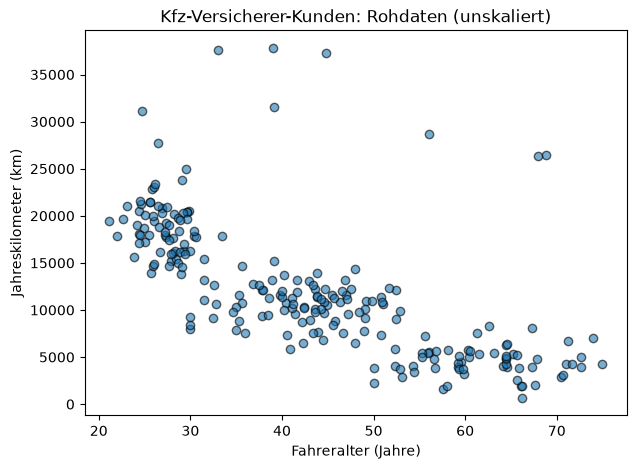

In [4]:
# I DO: Scatterplot der Rohdaten (unskaliert)

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.scatter(kunden["fahreralter"], kunden["jahreskilometer"], alpha=0.6, edgecolor="k")
plt.xlabel("Fahreralter (Jahre)")
plt.ylabel("Jahreskilometer (km)")
plt.title("Kfz-Versicherer-Kunden: Rohdaten (unskaliert)")
plt.show()

**Beobachtung:** Man erahnt vielleicht eine grobe Struktur, aber die Gruppen sind **nicht klar
voneinander abgegrenzt** — die Punktwolken verschwimmen ineinander. Das liegt zum Teil an der
natürlichen Überlappung der Gruppen, aber auch an einem technischen Problem, das wir gleich lösen:
**unterschiedliche Skalen**.

> ⚠️ **Common Pitfall:**
> `jahreskilometer` bewegt sich im Bereich von Tausenden, `fahreralter` nur im Bereich von
> Zehnern. Jeder Distanzberechnung (Euklidisch, wie in der Vorlesung besprochen) wird dadurch
> praktisch nur noch von `jahreskilometer` dominiert — das Merkmal mit den größeren Zahlen
> "gewinnt" automatisch, unabhängig davon, ob es inhaltlich wichtiger ist.

### Zwischenfazit

Du hast jetzt gesehen: Rohdaten allein reichen nicht, um Cluster verlässlich zu erkennen — die
unterschiedlichen Skalen der Merkmale verzerren jede Distanzberechnung. Bevor wir einen einzigen
Clustering-Algorithmus anwenden, müssen wir dieses Problem lösen.

## Schritt 3 — Normalisierung (Z-Transformation)

Erinnerst Du Dich an die Vorlesung? **Z-Transformation vor der Clusteranalyse ist Pflicht:**

$$z = \frac{x - \bar{x}}{s}$$

Jedes Merkmal wird so umgerechnet, dass es Mittelwert 0 und Standardabweichung 1 hat. Danach
tragen alle drei Merkmale (Alter, km, Unfälle) **gleichgewichtig** zur Distanzberechnung bei —
unabhängig von ihrer ursprünglichen Größenordnung.

`scikit-learn` übernimmt das für uns mit dem `StandardScaler`.

In [5]:
# I DO: Z-Transformation mit StandardScaler

from sklearn.preprocessing import StandardScaler

merkmale = ["fahreralter", "jahreskilometer", "unfallhistorie_3j"]
X = kunden[merkmale].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # fit: Mittelwert/Std berechnen, transform: anwenden

print("Mittelwert je Merkmal (sollte ~0 sein):", X_scaled.mean(axis=0).round(2))
print("Std je Merkmal (sollte 1 sein):        ", X_scaled.std(axis=0).round(2))

Mittelwert je Merkmal (sollte ~0 sein): [ 0. -0.  0.]
Std je Merkmal (sollte 1 sein):         [1. 1. 1.]


> 💡 **Good to know:**
> `fit_transform()` macht zwei Dinge in einem Schritt: **fit** berechnet Mittelwert und
> Standardabweichung jeder Spalte aus den Trainingsdaten, **transform** wendet die z-Transformation
> darauf an. Bei neuen Kunden würdest Du später nur noch `scaler.transform(...)` aufrufen — mit
> den bereits gelernten Werten, nicht neu berechnet.

Werfen wir noch einen Blick auf die skalierten Daten (jetzt Fahreralter vs. Unfallhistorie, damit
Du siehst, dass die Achsen jetzt vergleichbare Größenordnungen haben):

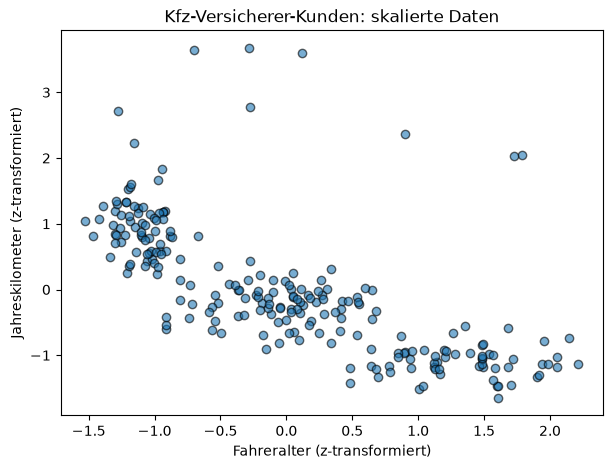

In [6]:
# I DO: Skalierte Daten visualisieren

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.6, edgecolor="k")
plt.xlabel("Fahreralter (z-transformiert)")
plt.ylabel("Jahreskilometer (z-transformiert)")
plt.title("Kfz-Versicherer-Kunden: skalierte Daten")
plt.show()

Jetzt bewegen sich beide Achsen in einer vergleichbaren Größenordnung (ungefähr −2 bis +3) —
die Basis für jede sinnvolle Distanzberechnung. Ab hier arbeiten wir ausschließlich mit
`X_scaled`.

## Schritt 4 — K-Means: Kunden um Zentroide gruppieren

**Analogie:** Stell Dir K Magnete vor, die zufällig im Merkmalsraum verteilt werden. Jeder Kunde
wird vom nächstgelegenen Magneten "angezogen" und einem Cluster zugeordnet. Dann springt jeder
Magnet in die Mitte seiner angezogenen Kunden — und das Spiel beginnt von vorne, bis sich nichts
mehr bewegt (**Konvergenz**).

Diese Magnete heißen **Zentroide**, und genau das ist die Grundidee von **K-Means**: Aus der
Vorlesung kennst Du die vier Schritte — Initialisierung, Zuordnung, Update, Konvergenztest.

> ⚠️ **Common Pitfall:**
> K-Means (Clustering) ist **nicht dasselbe** wie KNN aus Kapitel 4 (Klassifikation)! Beide
> nutzen zwar Distanzen, aber KNN braucht Labels zum Lernen, K-Means nicht.

Wir starten mit einer festen Wahl: **K = 3**, passend zu unseren drei simulierten Kundengruppen.

In [7]:
# I DO: K-Means mit K=3 anwenden

from sklearn.cluster import KMeans

kmeans_3 = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
kmeans_3.fit(X_scaled)

kunden["kmeans_cluster"] = kmeans_3.labels_
print("Anzahl Kunden je Cluster:")
print(kunden["kmeans_cluster"].value_counts().sort_index())

Anzahl Kunden je Cluster:
kmeans_cluster
0     54
1     66
2    108
Name: count, dtype: int64


> 💡 **Good to know:**
> `init="k-means++"` ist die aus der Vorlesung bekannte klügere Initialisierung (Arthur &
> Vassilvitskii, 2007) — sie vermeidet schlechte Zufalls-Startpunkte. `n_init=10` lässt den
> Algorithmus zehnmal mit unterschiedlichen Startpunkten laufen und behält das beste Ergebnis.

Jetzt visualisieren wir das Ergebnis — inklusive der drei Zentroide (als große Sterne markiert).
Da die Zentroide im skalierten Raum liegen, transformieren wir sie mit `scaler.inverse_transform()`
zurück in die ursprüngliche Einheit (Jahre / km), damit die Achsenbeschriftung interpretierbar
bleibt.

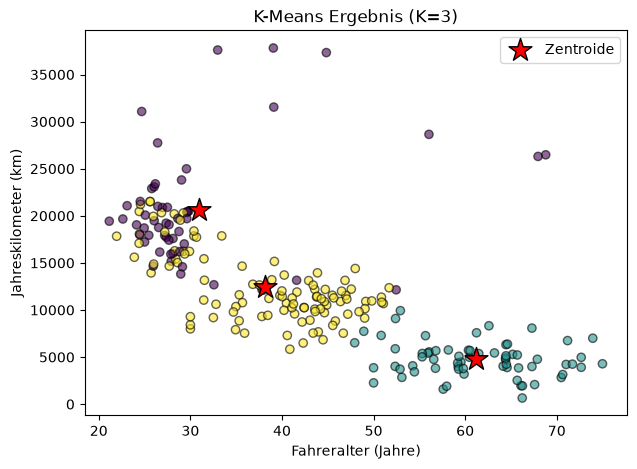

In [8]:
# I DO: Cluster-Zuordnung und Zentroide visualisieren

zentroide_original = scaler.inverse_transform(kmeans_3.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(kunden["fahreralter"], kunden["jahreskilometer"],
            c=kunden["kmeans_cluster"], cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(zentroide_original[:, 0], zentroide_original[:, 1],
            c="red", marker="*", s=300, edgecolor="black", label="Zentroide")
plt.xlabel("Fahreralter (Jahre)")
plt.ylabel("Jahreskilometer (km)")
plt.title("K-Means Ergebnis (K=3)")
plt.legend()
plt.show()

Jetzt sind die drei Gruppen klar farblich getrennt — und die roten Sterne markieren die
Zentroide, also die "Durchschnittskunden" jedes Clusters.

## Guided Practice — Cluster geschäftlich interpretieren

> 🎯 **Your Task:**
> Führe die Zelle unten aus. Sie berechnet für jeden Cluster den **Mittelwert** aller drei
> Merkmale — das hilft Dir, jedem Cluster ein geschäftlich sinnvolles Etikett zu geben (z. B.
> "Hochrisiko", "Standard", "Niedrigrisiko"), genau wie in der Vorlesung besprochen.

In [9]:
# WE DO: Cluster-Mittelwerte berechnen und interpretieren

cluster_profile = kunden.groupby("kmeans_cluster")[merkmale].mean().round(1)
print(cluster_profile)

                fahreralter  jahreskilometer  unfallhistorie_3j
kmeans_cluster                                                 
0                      30.9          20629.1                2.0
1                      61.2           4785.8                0.1
2                      38.2          12458.7                0.2


Schau Dir die Tabelle an: Welcher Cluster hat das jüngste Durchschnittsalter, die höchste
Kilometerleistung und die meisten Unfälle? Das ist vermutlich Dein "Hochrisiko"-Cluster. Welcher
Cluster ist am ältesten, fährt am wenigsten und hat kaum Unfälle? Das ist Dein
"Niedrigrisiko"-Cluster.

> 💡 **Good to know:**
> Genau diese Interpretation — nicht der Algorithmus selbst — ist der Schritt, der aus
> "drei Zahlengruppen" ein **geschäftlich nutzbares Ergebnis** macht: eine Tarifierungslogik pro
> Cluster.

### Zwischenfazit

Du hast jetzt K-Means einmal komplett durchgespielt: normalisieren, fitten, Zentroide
visualisieren, Cluster inhaltlich interpretieren. Eine Frage ist aber noch offen: **Woher wussten
wir eigentlich, dass K=3 die richtige Wahl war?** Genau darum geht es im nächsten Schritt.

## Schritt 5 — Aber woher wussten wir, dass K=3 richtig ist?

Ehrlicherweise: Wir haben K=3 nur deshalb gewählt, weil wir den Datensatz selbst mit drei Gruppen
gebaut haben. In der Praxis kennst Du die "richtige" Anzahl an Clustern **nicht im Voraus**.

Genau dafür gibt es die **Elbow-Methode**, die Du aus der Vorlesung kennst:

1. Berechne für K = 1, 2, 3, ..., 10 jeweils K-Means und notiere die **WCSS**
   (Within-Cluster Sum of Squares — bei `scikit-learn` als `kmeans.inertia_` verfügbar).
2. Plotte WCSS gegen K.
3. Suche den "Knick" (Elbow) — den Punkt, an dem die Kurve von steil zu flach wechselt.

> 💡 **Good to know:**
> WCSS sinkt **immer**, wenn K steigt (bei K = Anzahl Kunden wäre WCSS = 0, aber nutzlos). Der
> Elbow markiert den Punkt, an dem zusätzliche Cluster nur noch marginale Verbesserung bringen.

> 🎯 **Your Task:**
> Vervollständige den Code unten: Schreibe eine Schleife über K = 1 bis 10, trainiere jeweils
> ein `KMeans`-Modell auf `X_scaled` und sammle `kmeans.inertia_` (= WCSS) in der Liste
> `wcss_werte`. Das Muster kennst Du bereits aus den KNN-Notebooks aus Kapitel 4 — nur dass wir
> hier statt der Accuracy die WCSS aufzeichnen.

In [ ]:
# =========================================================
# 🎯 EXERCISE: Elbow-Methode - optimales K finden
# =========================================================
# Instruction: Ersetze die Platzhalter (???) durch gültigen Code.

k_werte = range(1, 11)   # K von 1 bis 10 testen
wcss_werte = []           # hier sammeln wir die WCSS je K

for k in k_werte:
    # 1. Erstelle eine KMeans-Instanz mit n_clusters=k (nutze auch hier random_state=42, n_init=10)
    kmeans_k = ???

    # 2. Fitte das Modell auf X_scaled
    ???

    # 3. Lies die WCSS aus (Attribut .inertia_) und hänge sie an wcss_werte an
    wcss_werte.append(???)

print("WCSS je K:", [round(w, 1) for w in wcss_werte])

Jetzt plotten wir die Elbow-Kurve, um den Knick visuell zu erkennen.

In [ ]:
# =========================================================
# 🎯 EXERCISE: Elbow-Kurve plotten
# =========================================================
# Instruction: Ersetze die Platzhalter (???) durch gültigen Code.

plt.figure(figsize=(7, 5))
plt.plot(???, ???, marker="o")   # x-Achse: k_werte, y-Achse: wcss_werte
plt.xlabel("Anzahl Cluster K")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow-Kurve zur Bestimmung des optimalen K")
plt.xticks(list(k_werte))
plt.show()

> 🎯 **Your Task (Interpretation):**
> Schau Dir die Kurve an: Bei welchem K flacht sie deutlich ab? Passt dieser Wert zu den drei
> Kundengruppen, die wir simuliert haben? Notiere Deine Beobachtung kurz für Dich — im
> `loesung.ipynb` findest Du eine ausführliche Musterinterpretation.

In [ ]:
# TODO: Trage hier Deine eigene Beobachtung als Kommentar ein.
# Bei welchem K siehst Du den deutlichsten Knick in der Elbow-Kurve?

optimales_k = ???  # deine Einschätzung als Ganzzahl
print(f"Meine Einschätzung für das optimale K: {optimales_k}")

## Schritt 6 — DBSCAN: Dichtebasiertes Clustering & Ausreißererkennung

K-Means hat einen blinden Fleck: Es **zwingt jeden Punkt** in einen Cluster — auch echte
Ausreißer. Für unsere acht bewusst eingebauten "Verdachtsfälle" (hohe km, viele Unfälle) ist das
unpraktisch: Sie werden einfach dem nächstgelegenen Zentroid zugeschlagen, statt als Anomalie
erkannt zu werden.

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) löst das anders: Es
gruppiert Punkte über **Dichte**, nicht über Distanz zu einem Zentrum, und kennt einen dritten
Punkttyp neben "gehört zu Cluster A" / "gehört zu Cluster B": **Rauschen** (Label `-1`).

Zur Erinnerung aus der Vorlesung, die zwei Parameter:
- **ε (eps):** Radius der Nachbarschaft um jeden Punkt.
- **MinPts (`min_samples`):** Wie viele Nachbarn braucht ein Punkt im ε-Radius, um als
  **Kernpunkt** zu gelten?

Punkte, die weder Kernpunkt noch im Radius eines Kernpunkts liegen, werden zu **Rauschpunkten**.

> 🎯 **Your Task:**
> Führe die Zelle unten aus. Wir starten mit `eps=0.5` und `min_samples=5` auf den skalierten
> Daten `X_scaled` — beobachte, wie viele Cluster gefunden werden und wie viele Punkte als
> Rauschen (`-1`) markiert werden.

In [10]:
# WE DO: DBSCAN mit ersten Parametern anwenden

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
kunden["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

anzahl_rauschen = (kunden["dbscan_cluster"] == -1).sum()
anzahl_cluster = kunden["dbscan_cluster"].nunique() - (1 if -1 in kunden["dbscan_cluster"].values else 0)
print(f"Gefundene Cluster: {anzahl_cluster}")
print(f"Rauschpunkte (Label -1): {anzahl_rauschen}")

Gefundene Cluster: 4
Rauschpunkte (Label -1): 23


> ⚠️ **Common Pitfall:**
> Mit `eps=0.5` markiert DBSCAN auf unseren Daten vermutlich **sehr viele** Punkte als Rauschen —
> das ε ist zu klein gewählt, sodass selbst Punkte innerhalb der "echten" Gruppen zu weit
> auseinanderliegen, um sich gegenseitig als Nachbarn zu erkennen. Das ist ein typisches erstes
> Ergebnis beim DBSCAN-Tuning: **Parameter passen selten beim ersten Versuch.**

## Guided Practice — DBSCAN-Parameter tunen

> 🎯 **Your Task:**
> Probiere ein größeres `eps` aus (z. B. `eps=0.8`) und beobachte, wie sich die Anzahl der
> gefundenen Cluster und Rauschpunkte verändert. Passe danach ggf. `min_samples` an.

In [ ]:
# =========================================================
# 🎯 EXERCISE: DBSCAN-Parameter anpassen
# =========================================================
# Instruction: Probiere verschiedene Werte für eps und min_samples aus, bis die
# acht bewussten Ausreißer (hohe km, viele Unfälle) als Rauschen erkannt werden,
# aber die drei "echten" Kundengruppen trotzdem als Cluster erhalten bleiben.

dbscan_tuned = DBSCAN(eps=???, min_samples=???)
kunden["dbscan_cluster_tuned"] = dbscan_tuned.fit_predict(X_scaled)

anzahl_rauschen_tuned = (kunden["dbscan_cluster_tuned"] == -1).sum()
anzahl_cluster_tuned = kunden["dbscan_cluster_tuned"].nunique() - (1 if -1 in kunden["dbscan_cluster_tuned"].values else 0)
print(f"Gefundene Cluster: {anzahl_cluster_tuned}")
print(f"Rauschpunkte (Label -1): {anzahl_rauschen_tuned}")

Schauen wir uns konkret an, **welche** Kunden als Rauschen erkannt wurden — und ob das
inhaltlich Sinn ergibt.

In [ ]:
# TODO: Filtere den DataFrame 'kunden' auf alle Zeilen, bei denen dbscan_cluster_tuned == -1 ist
rauschpunkte = kunden[???]
print(f"Anzahl identifizierter Rauschpunkte: {len(rauschpunkte)}")
rauschpunkte[merkmale]

Visualisieren wir das Ergebnis noch einmal, damit Du die Rauschpunkte (meist als eigene Farbe
bzw. Symbol dargestellt) direkt sehen kannst. Damit diese Zelle unabhängig von Deiner eigenen
Parameterwahl oben funktioniert, wiederholen wir den DBSCAN-Fit hier noch einmal explizit mit den
empfohlenen Werten `eps=0.8, min_samples=5`.

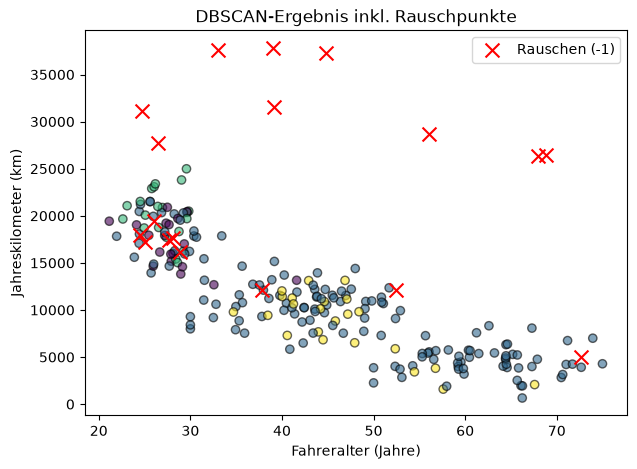

In [11]:
# I DO: DBSCAN-Ergebnis mit empfohlenen Parametern visualisieren (Rauschen in Rot mit X)

dbscan_demo = DBSCAN(eps=0.8, min_samples=5)
labels_demo = dbscan_demo.fit_predict(X_scaled)
ist_rauschen = labels_demo == -1

plt.figure(figsize=(7, 5))
plt.scatter(kunden.loc[~ist_rauschen, "fahreralter"], kunden.loc[~ist_rauschen, "jahreskilometer"],
            c=labels_demo[~ist_rauschen], cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(kunden.loc[ist_rauschen, "fahreralter"], kunden.loc[ist_rauschen, "jahreskilometer"],
            c="red", marker="x", s=100, label="Rauschen (-1)")
plt.xlabel("Fahreralter (Jahre)")
plt.ylabel("Jahreskilometer (km)")
plt.title("DBSCAN-Ergebnis inkl. Rauschpunkte")
plt.legend()
plt.show()

> 🎯 **Your Task (Interpretation):**
> Warum könnte es für den Versicherer geschäftlich wertvoll sein, dass DBSCAN diese Kunden
> **explizit als Anomalie** markiert, statt sie einem Cluster zuzuordnen? Denk an mögliche
> Anwendungsfälle wie Betrugserkennung oder individuelle Risikoprüfung.

In [ ]:
# TODO: Schreibe Deine Interpretation als Kommentar oder print()-Ausgabe.
# Warum ist die explizite Rauschen-Erkennung von DBSCAN hier geschäftlich wertvoll?

print("Meine Interpretation: ???")

### Zwischenfazit

Du kennst jetzt zwei sehr unterschiedliche Sichtweisen auf denselben Datensatz: K-Means (jeder
Kunde MUSS in ein Cluster) und DBSCAN (Kunden können explizit als Rauschen markiert werden). Zum
Abschluss schauen wir uns noch einen dritten Ansatz an, der K erst gar nicht vorab braucht:
**Hierarchisches Clustering**.

## Schritt 7 — Hierarchisches Clustering & Dendrogramm

Der dritte Ansatz aus der Vorlesung: **Agglomeratives (hierarchisches) Clustering** baut von
unten nach oben einen Baum (**Dendrogramm**) auf. Zu Beginn ist jeder Kunde sein eigenes Cluster;
dann werden schrittweise die beiden ähnlichsten Cluster verschmolzen, bis am Ende alles in einem
gemeinsamen Wurzelcluster steckt.

Der große Unterschied zu K-Means: Du legst **K nicht vorab fest** — Du schneidest den fertigen
Baum erst hinterher auf der gewünschten Höhe durch. Wir nutzen **Ward-Linkage** (aus der
Vorlesung bekannt als die Variante, die — ähnlich wie K-Means — die Streuung innerhalb der
Cluster minimiert).

> 💡 **Good to know:**
> Weil der Rechenaufwand von hierarchischem Clustering mit O(n²) bis O(n³) wächst, nutzen wir
> hier zur Übersichtlichkeit nur eine **Stichprobe** von 40 Kunden für das Dendrogramm — sonst
> wäre der Baum mit 228 Blättern kaum noch lesbar.

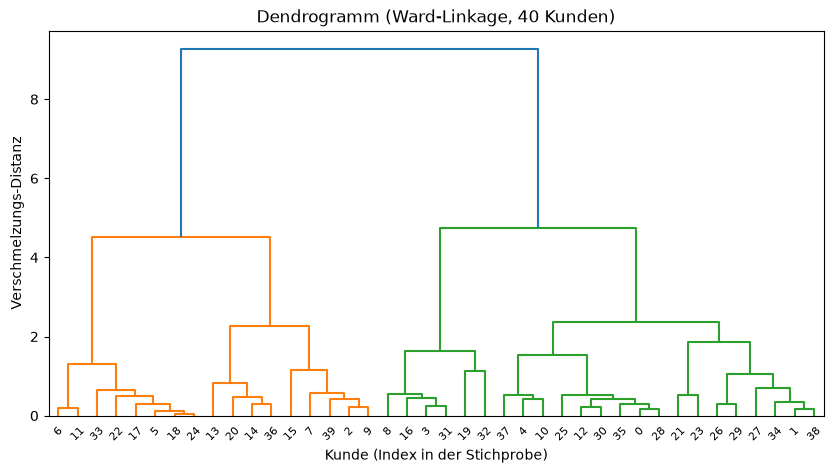

In [12]:
# I DO: Dendrogramm für eine Stichprobe von 40 Kunden

from scipy.cluster.hierarchy import dendrogram, linkage

stichprobe_idx = rng.choice(len(X_scaled), size=40, replace=False)
X_stichprobe = X_scaled[stichprobe_idx]

verknuepfungen = linkage(X_stichprobe, method="ward")  # Ward-Linkage, siehe Vorlesung

plt.figure(figsize=(10, 5))
dendrogram(verknuepfungen)
plt.xlabel("Kunde (Index in der Stichprobe)")
plt.ylabel("Verschmelzungs-Distanz")
plt.title("Dendrogramm (Ward-Linkage, 40 Kunden)")
plt.show()

Ein horizontaler Schnitt durch den Baum bei einer bestimmten Höhe ergibt die Cluster. Jetzt
wenden wir hierarchisches Clustering auf **alle** Kunden an (mit `AgglomerativeClustering`,
K=3 vorgegeben, damit wir direkt mit K-Means vergleichen können) und schauen, ob dieselben
Kundengruppen herauskommen.

In [13]:
# I DO: AgglomerativeClustering mit K=3 auf alle Kunden anwenden

from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=3, linkage="ward")
kunden["agglo_cluster"] = agglo.fit_predict(X_scaled)

kunden.groupby("agglo_cluster")[merkmale].mean().round(1)

,fahreralter,jahreskilometer,unfallhistorie_3j
agglo_cluster,,,
0,37.1,13504.9,0.3
1,62.2,4490.3,0.1
2,33.2,20280.0,2.6


Vergleiche diese Tabelle mit dem K-Means-Cluster-Profil von weiter oben — die Mittelwerte
sollten sehr ähnlich aussehen! Um es noch direkter zu sehen, erstellen wir eine **Kreuztabelle**
(`pd.crosstab`), die zeigt, wie oft ein K-Means-Cluster mit einem Agglomerative-Cluster
übereinstimmt.

In [14]:
# WE DO: K-Means- und Agglomerative-Cluster-Zuordnung vergleichen

vergleich = pd.crosstab(kunden["kmeans_cluster"], kunden["agglo_cluster"])
print(vergleich)

agglo_cluster     0   1   2
kmeans_cluster             
0                19   0  35
1                 6  60   0
2               108   0   0


Wenn (fast) alle Kunden konzentriert in wenigen Zellen dieser Tabelle liegen (statt gleichmäßig
verteilt), bedeutet das: **Beide Verfahren finden im Wesentlichen dieselben drei Gruppen** — nur
mit unterschiedlicher interner Nummerierung (Cluster 0 bei K-Means muss nicht Cluster 0 bei
Agglomerative sein). Das ist ein gutes Zeichen: Die gefundene Struktur ist **robust** gegenüber
der Wahl des Algorithmus.

## Mini-Exercise / Self-Check — K-Means vs. DBSCAN im Geschäftskontext

Du hast jetzt beide Verfahren auf demselben Datensatz angewendet. Zwei konkrete Geschäftsfälle
des Kfz-Versicherers:

1. **Tarifierung:** Jedem der 228 Bestandskunden soll eine von mehreren Prämienklassen
   zugewiesen werden (jeder Kunde MUSS in eine Klasse fallen).
2. **Betrugs-/Anomalieerkennung:** Auffällige Kunden (z. B. ungewöhnlich hohe Kilometerangaben
   kombiniert mit vielen Unfällen) sollen für eine manuelle Prüfung markiert werden — die meisten
   Kunden sollen dabei explizit *nicht* markiert werden.

> 🎯 **Your Task:**
> Ordne jedem der beiden Geschäftsfälle den besser passenden Algorithmus (K-Means oder DBSCAN)
> zu und begründe kurz, warum — nutze dabei, was Du in diesem Notebook über beide Verfahren
> beobachtet hast (Punkt "muss immer zugeordnet werden" vs. "kann explizit als Rauschen markiert
> werden").

In [ ]:
# TODO: Trage Deine Zuordnung und Begründung als Kommentare bzw. print()-Ausgaben ein.

algorithmus_tarifierung = "???"          # "K-Means" oder "DBSCAN"
begruendung_tarifierung = "???"

algorithmus_anomalieerkennung = "???"    # "K-Means" oder "DBSCAN"
begruendung_anomalieerkennung = "???"

print(f"Tarifierung -> {algorithmus_tarifierung}: {begruendung_tarifierung}")
print(f"Anomalieerkennung -> {algorithmus_anomalieerkennung}: {begruendung_anomalieerkennung}")

## Summary & Key Takeaways

- **Unsupervised Learning** sucht Struktur in Daten **ohne** vorgegebene Labels — das Ergebnis
  (Cluster-Zugehörigkeit) ist die Ausgabe, nicht die Eingabe.
- **Z-Transformation (Normalisierung) ist Pflicht** vor jeder Clusteranalyse — sonst dominieren
  Merkmale mit großem Wertebereich (wie `jahreskilometer`) die Distanzberechnung.
- **K-Means** gruppiert Kunden iterativ um K Zentroide; `kmeans.inertia_` liefert die WCSS. Jeder
  Punkt wird zwangsläufig einem Cluster zugeordnet — ideal für Tarifierung/Segmentierung, aber
  ausreißerempfindlich.
- Die **Elbow-Methode** plottet WCSS gegen K und sucht den Knick, an dem zusätzliche Cluster nur
  noch marginalen Nutzen bringen — bei unserem Datensatz war das klar K=3.
- **DBSCAN** gruppiert über Dichte (ε, `min_samples`) statt über Distanz zu einem Zentrum und
  markiert Ausreißer explizit als **Rauschen** (Label `-1`) — ideal für Anomalie-/
  Betrugserkennung.
- **Hierarchisches Clustering** (Dendrogramm, Ward-Linkage) baut Cluster bottom-up auf, ohne K
  vorab festzulegen, und lieferte hier im Wesentlichen dieselben drei Gruppen wie K-Means — ein
  Zeichen für eine robuste Cluster-Struktur.
- Die Wahl des richtigen Algorithmus ist eine **Geschäftsentscheidung**: K-Means/Hierarchisch für
  "jeder Kunde braucht eine Gruppe", DBSCAN wenn Ausreißer selbst die interessante Information
  sind.

**Weiter geht's:** Im nächsten Schritt des Moduls wechseln wir von klassischem Machine Learning
zu modernen KI-Werkzeugen — bleib gespannt!